In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv('Dataset.csv')
# df.head()
# df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181774 entries, 0 to 181773
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 181774 non-null  int64  
 1   accident_id                181774 non-null  object 
 2   state                      181774 non-null  object 
 3   area_type                  181774 non-null  object 
 4   latitude                   172833 non-null  float64
 5   longitude                  172833 non-null  float64
 6   road_type                  181774 non-null  object 
 7   road_condition             181774 non-null  object 
 8   road_lighting              176348 non-null  object 
 9   number_of_lanes            174507 non-null  float64
 10  speed_limit_kmph           172666 non-null  float64
 11  estimated_speed_kmph       181774 non-null  float64
 12  junction_type              176330 non-null  object 
 13  traffic_signal_present     17

In [73]:
df.drop(columns=['Unnamed: 0'], axis=0 , inplace=True)

In [74]:
df.isnull().sum().sort_values(ascending=False)

visibility_km                10950
speed_limit_kmph              9108
temperature_c                 9106
latitude                      8941
longitude                     8941
driving_experience_years      8018
driver_age                    8018
vehicle_age_years             8018
hospitalization_required      7285
median_present                7273
number_of_lanes               7267
traffic_signal_present        7244
driver_gender                 5483
junction_type                 5444
road_lighting                 5426
weather_condition             3660
num_vehicles                     0
vehicle_type                     0
num_injuries                     0
num_fatalities                   0
accident_severity                0
police_called                    0
ambulance_called                 0
emergency_services_called        0
primary_cause                    0
vehicle_condition                0
accident_id                      0
helmet_seatbelt_used             0
fatigue_involved    

In [75]:
df.describe()

,latitude,longitude,number_of_lanes,speed_limit_kmph,estimated_speed_kmph,visibility_km,temperature_c,rainfall_mm,driver_age,driving_experience_years,vehicle_age_years,num_vehicles,num_injuries,num_fatalities,insurance_claim_amount
count,172833.000000,172833.000000,174507.000000,172666.000000,181774.000000,170824.000000,172668.000000,181774.000000,173756.000000,173756.000000,173756.000000,181774.000000,181774.000000,181774.000000,181774.000000
mean,21.763953,77.994083,2.847995,58.855131,61.690569,4.913705,22.195228,3.481500,36.482193,16.723268,5.482622,2.536980,1.095003,0.124886,39293.278208
std,8.741293,15.178540,1.421113,23.127101,29.593928,2.851364,8.148391,10.410316,12.820925,11.906786,5.392957,1.453871,1.408469,0.540361,38299.276186
min,-89.993206,-179.316379,1.000000,20.000000,5.000000,0.020000,2.000000,0.000000,13.000000,0.000000,0.000000,1.000000,0.000000,-1.000000,0.000000
25%,17.837145,75.583818,2.000000,40.000000,39.900000,2.660000,15.600000,0.000000,27.000000,7.100000,1.600000,2.000000,0.000000,0.000000,12205.000000
50%,23.357313,77.914047,2.000000,60.000000,57.300000,4.710000,22.300000,0.000000,36.000000,16.000000,3.800000,2.000000,1.000000,0.000000,27781.000000
75%,26.646575,82.090192,4.000000,70.000000,78.200000,7.360000,28.800000,0.000000,45.000000,24.900000,7.600000,3.000000,2.000000,0.000000,54202.000000
max,89.967149,179.807326,6.000000,120.000000,160.000000,10.850000,47.000000,252.100000,102.000000,55.000000,30.000000,24.000000,13.000000,15.000000,434334.000000


- Min max values of each column is Justify
- estimated_speed_kmph, rainfall_mm, insurance_claim_amount is hogh ly ditributed by comapring mean and sd value 
- For num_fatalities min value is -1 which is not possible

## Univariant Analysis

In [76]:
# Outliers detection
int_cols = df.select_dtypes(include=['float64','int64']).columns
for col in int_cols:
    print(col,"==>",df[col].unique())
int_cols

latitude ==> [15.7410672  30.2111265  23.78297177 ... 29.57750844 27.54434377
 18.19726781]
longitude ==> [74.55504745 75.46189675 86.28110307 ... 82.37117505 82.83045526
 76.64696546]
number_of_lanes ==> [ 6.  2.  3.  1.  4. nan]
speed_limit_kmph ==> [ nan 120.  60.  40.  80.  30.  70. 100.  50.  20.]
estimated_speed_kmph ==> [ 80.8  96.2  76.4 ...   6.7 152.4   5.8]
visibility_km ==> [ 3.76  4.71  3.16 ... 10.74 10.8  10.68]
temperature_c ==> [ 9.   nan 28.8 12.8 18.4 30.3 23.6 32.9 22.2 33.9 29.6 22.8 31.9 34.5
 17.7 10.1 24.8 26.3 15.  26.4 19.4 18.9 19.  24.6 12.  30.7 33.1 34.2
 20.  15.8 19.5 14.3  8.5 28.4 18.6 16.8 30.9 19.9 24.7 23.8 19.6 28.5
  9.3 12.3 33.6 25.4 36.6 28.9 15.5 28.6 21.1 25.2 10.6 12.1 27.6 16.7
 22.1 37.4  3.9  6.3 19.7 21.6 18.3  7.2 17.5 26.7 18.2 21.  31.3 24.5
 23.2 32.2 25.5  8.4 22.6 26.5 30.4 12.7 26.9 29.5 16.3 25.7 35.3 14.
 29.3 29.9 32.  23.3 27.5 28.3 15.4 41.8 20.6 18.1 28.2 23.7 13.3 35.8
 17.6 23.   4.7 30.2 16.5 21.8 11.4 22.7 17.8 23.1 32.4

Index(['latitude', 'longitude', 'number_of_lanes', 'speed_limit_kmph',
       'estimated_speed_kmph', 'visibility_km', 'temperature_c', 'rainfall_mm',
       'driver_age', 'driving_experience_years', 'vehicle_age_years',
       'num_vehicles', 'num_injuries', 'num_fatalities',
       'insurance_claim_amount'],
      dtype='object')

In [77]:
df[int_cols].isnull().sum()

latitude                     8941
longitude                    8941
number_of_lanes              7267
speed_limit_kmph             9108
estimated_speed_kmph            0
visibility_km               10950
temperature_c                9106
rainfall_mm                     0
driver_age                   8018
driving_experience_years     8018
vehicle_age_years            8018
num_vehicles                    0
num_injuries                    0
num_fatalities                  0
insurance_claim_amount          0
dtype: int64

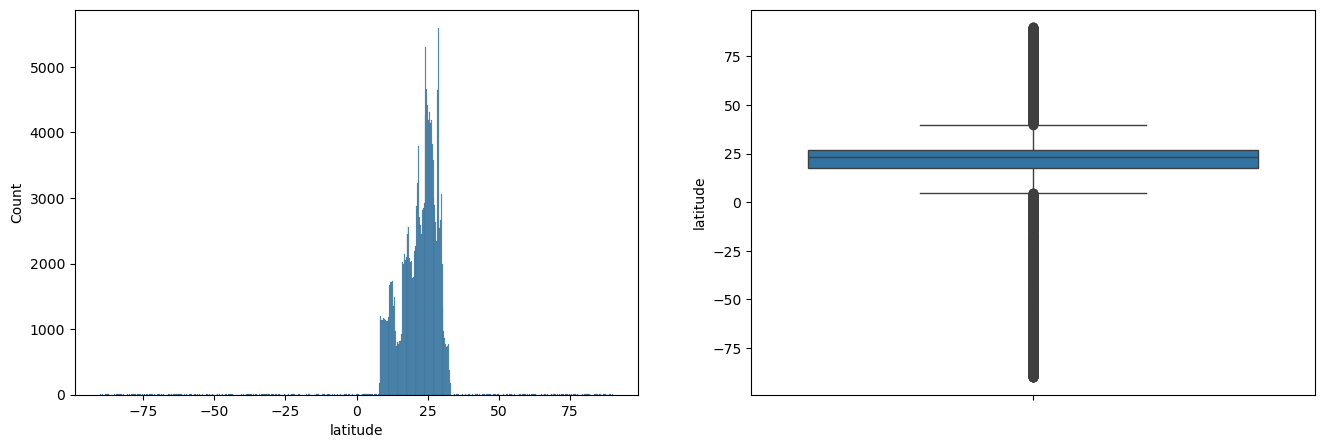

In [78]:
# latitude
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.histplot(df['latitude'])
# plt.xlim(0, 50)

plt.subplot(1,2,2)
sns.boxplot(df['latitude'])

plt.show() 

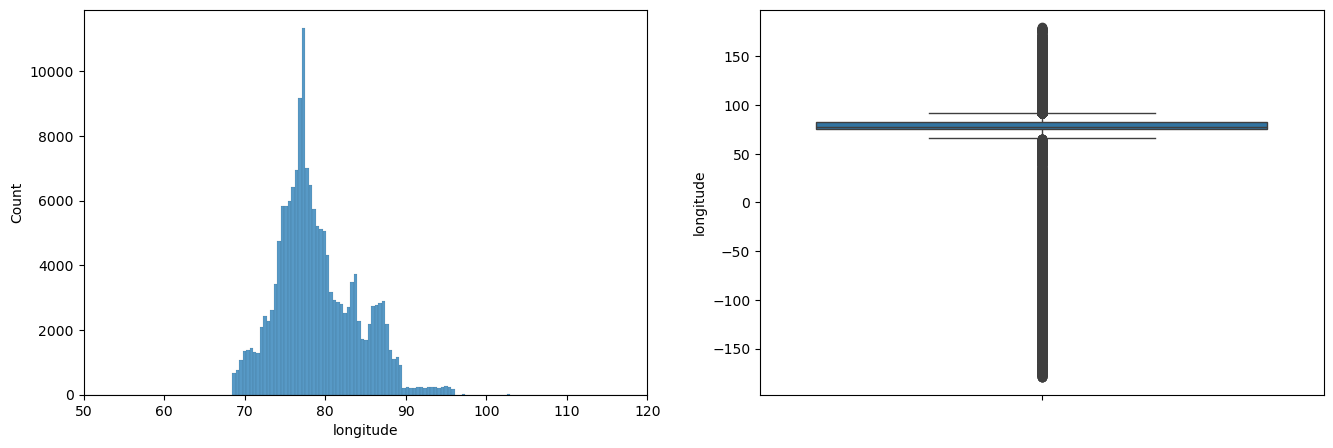

In [79]:
# longitude
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['longitude'])
plt.xlim(50, 120)

plt.subplot(1,2,2)
sns.boxplot(df["longitude"])
# plt.ylim(0,120)
plt.show()

- As we see there is mostly value beteween 70-90
- but there is many mid outlier but as my opinion this is ralistic data data 

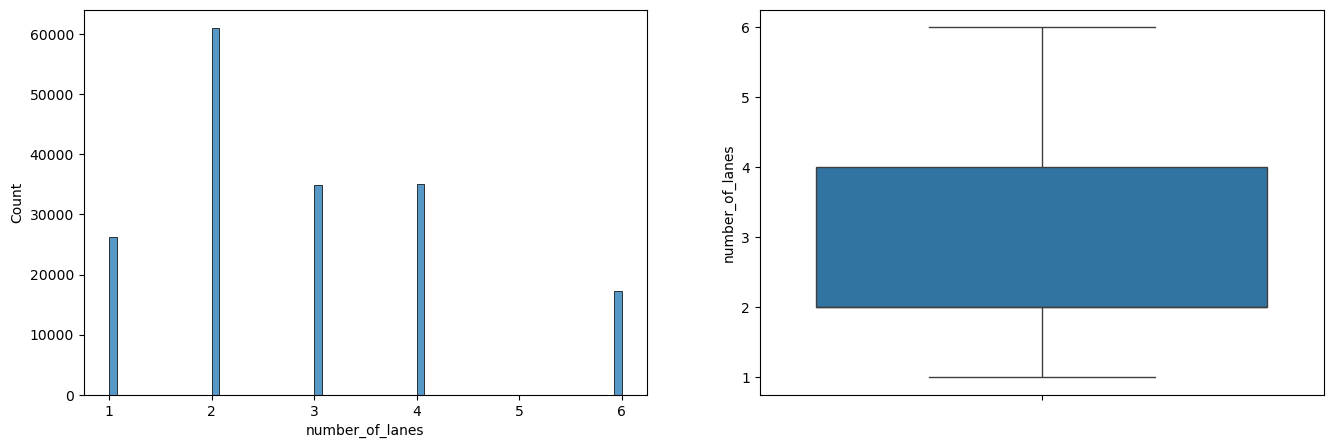

In [80]:
# number_of_lanes
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['number_of_lanes'])

plt.subplot(1,2,2)
sns.boxplot(df['number_of_lanes'])

plt.show()


Maximum roads are 2 lane road

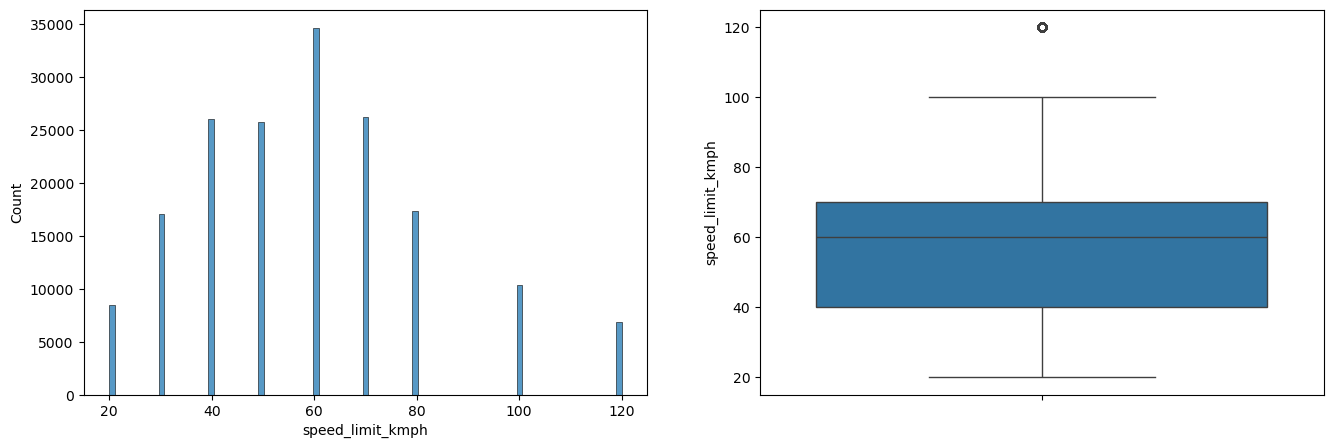

In [81]:
# speed_limit_kmph
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['speed_limit_kmph'])

plt.subplot(1,2,2)
sns.boxplot(df['speed_limit_kmph'])

plt.show()
# Conclusion speed_limit_kmph has outliers, we can remove the outliers

Speed Limit in many road are beteween 40-80

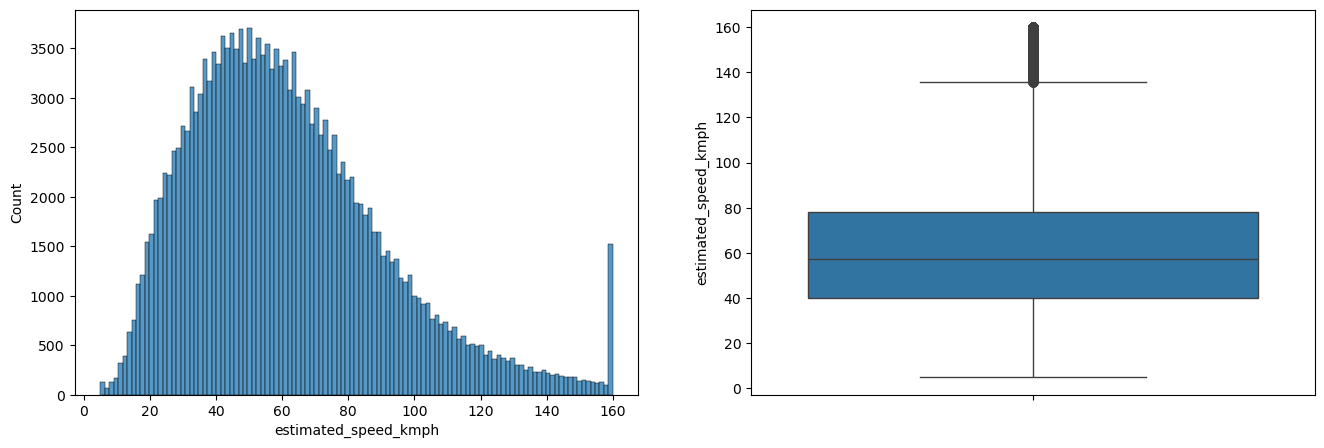

In [82]:
# estimated_speed_kmph
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['estimated_speed_kmph'])

plt.subplot(1,2,2)
sns.boxplot(df['estimated_speed_kmph'])

plt.show()

Estimated_speed_Kmph is mostly in beteween 20-80 but there is some outier need to be fix

In [83]:
Q1 = df['estimated_speed_kmph'].quantile(0.25)
Q3 = df['estimated_speed_kmph'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['estimated_speed_kmph'] >= lower_bound) & (df['estimated_speed_kmph'] <= upper_bound)]

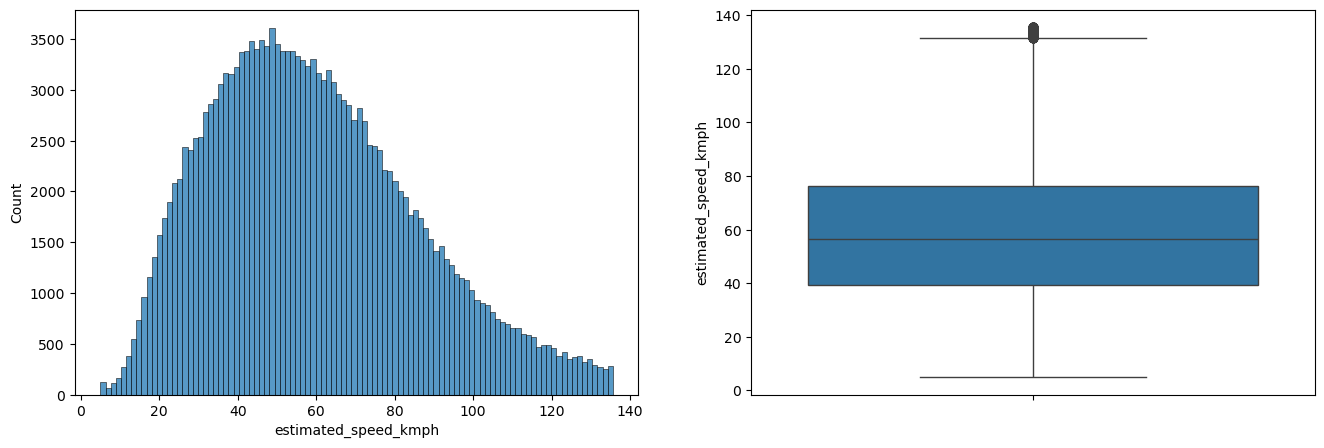

In [84]:
# estimated_speed_kmph after removing outliers
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['estimated_speed_kmph'])

plt.subplot(1,2,2)
sns.boxplot(df['estimated_speed_kmph'])

plt.show()

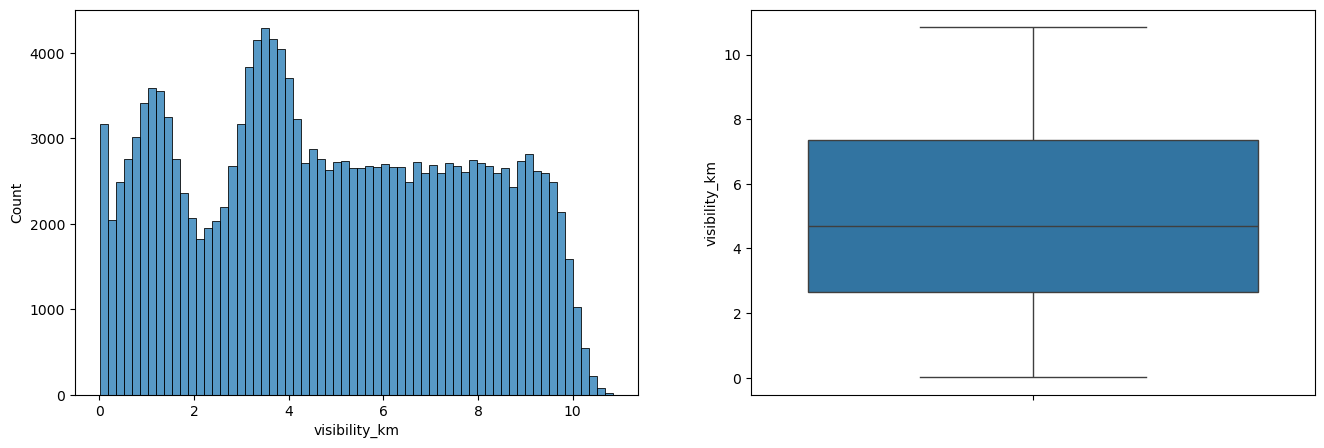

In [85]:
# response_time_minutes and vehicle_age_years outlier
# visibility_km
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['visibility_km'])

plt.subplot(1,2,2)
sns.boxplot(df['visibility_km'])

plt.show()
# conclusion visibility_km has no outliers

Visibilty data is weell justify no need any operation

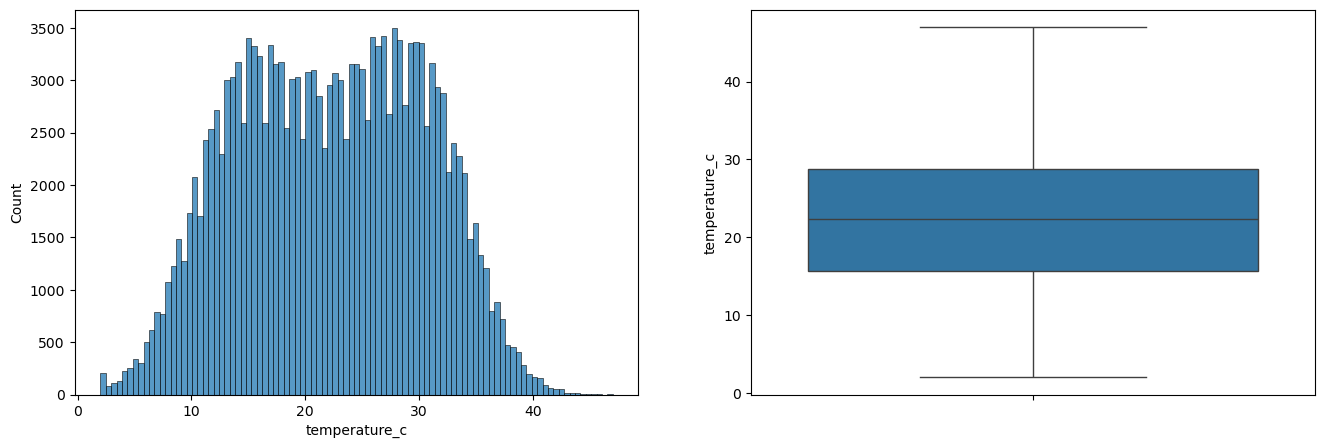

In [86]:
# temperature_c
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['temperature_c'])

plt.subplot(1,2,2)
sns.boxplot(df['temperature_c'])

plt.show()
# Conclusion temperature_c has no outliers

Temperature is mostly beteween in 10-35 

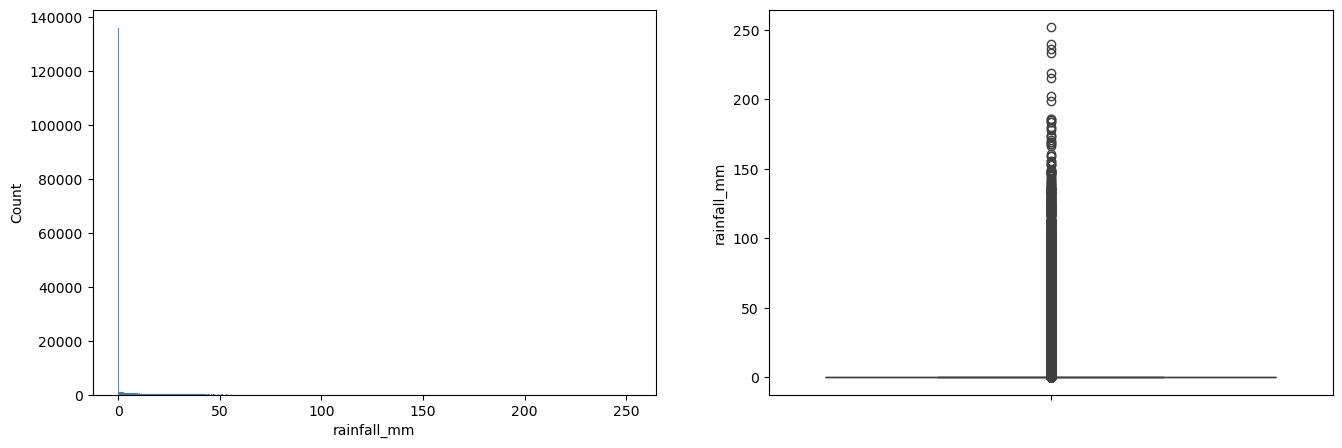

In [87]:
# rainfall_mm
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['rainfall_mm'])

plt.subplot(1,2,2)
sns.boxplot(df['rainfall_mm'])

plt.show()

Maximum area is dry but there is some area which conatain heavy rainfall


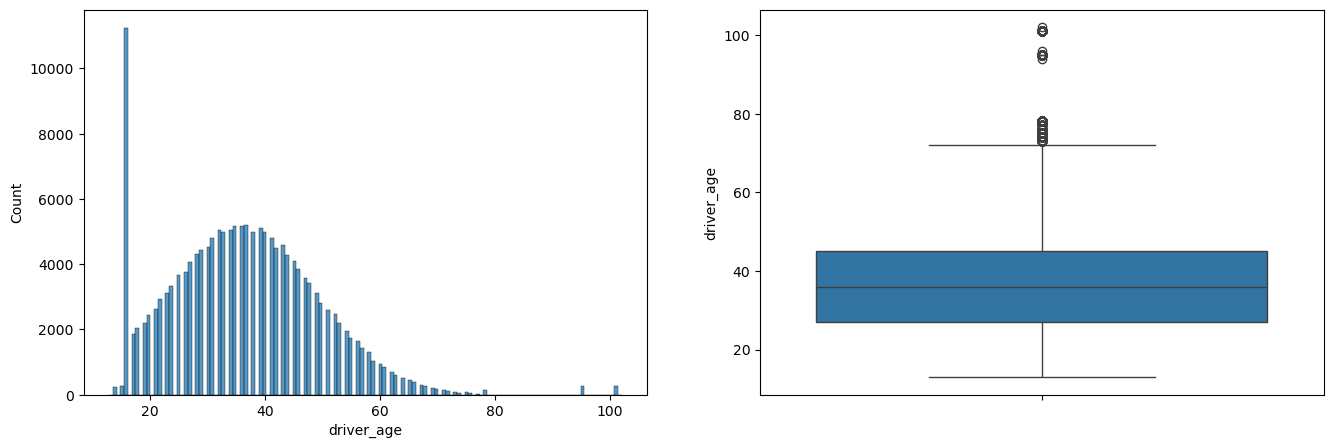

In [88]:
# driver_age
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['driver_age'])

plt.subplot(1,2,2)
sns.boxplot(df['driver_age'])

plt.show()

- Avereage age of driver is 25-60 but outside that it might be an outlier
- operation needed to remove the outlier

In [89]:
# Remove outliers
df = df[(df['driver_age'] >= 18) & (df['driver_age'] <= 70)]

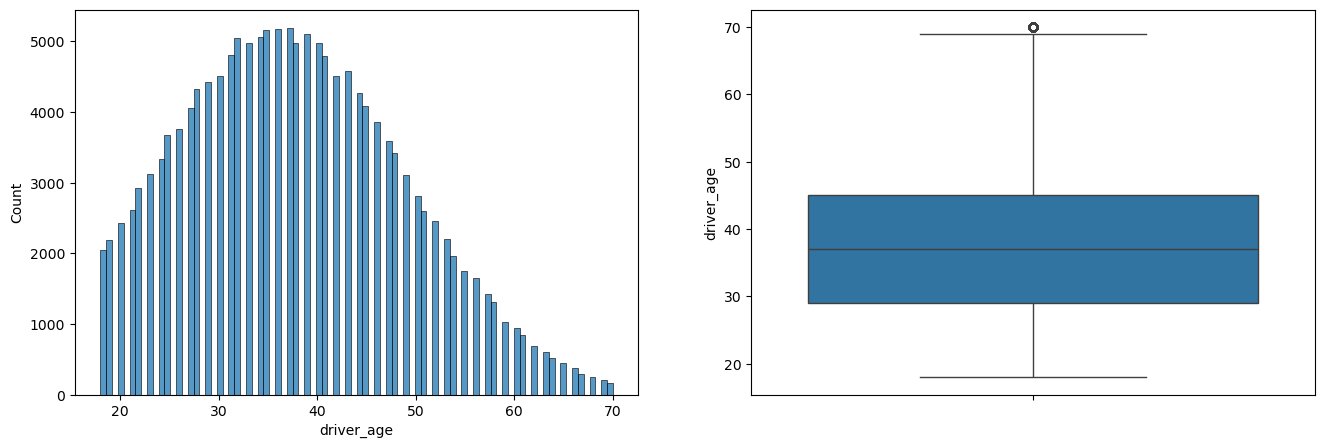

In [90]:
# driver_age after removing outliers
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['driver_age'])

plt.subplot(1,2,2)
sns.boxplot(df['driver_age'])

plt.show()

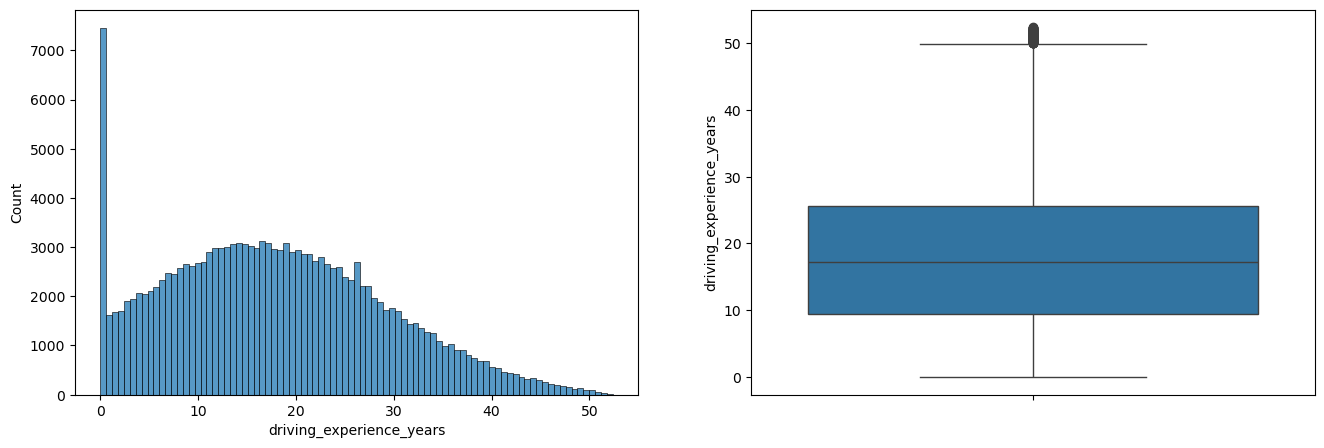

In [91]:
# driving_experience_years
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['driving_experience_years'])

plt.subplot(1,2,2)
sns.boxplot(df['driving_experience_years'])

plt.show()
# Conclusion driving_experience_years has outliers, we can remove the outliers

- Driver experience year is zero for maximum driver, but also there is also some experienced driver

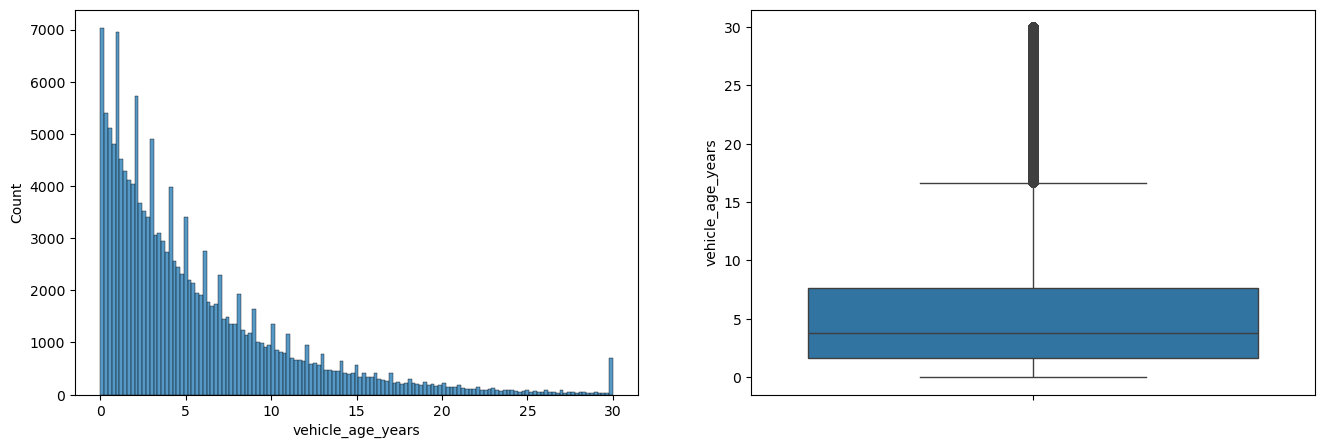

In [92]:
# vehicle_age_years
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['vehicle_age_years'])

plt.subplot(1,2,2)
sns.boxplot(df['vehicle_age_years'])

plt.show()

maximum vehicle is new but there are some vehicle whose age is 30 

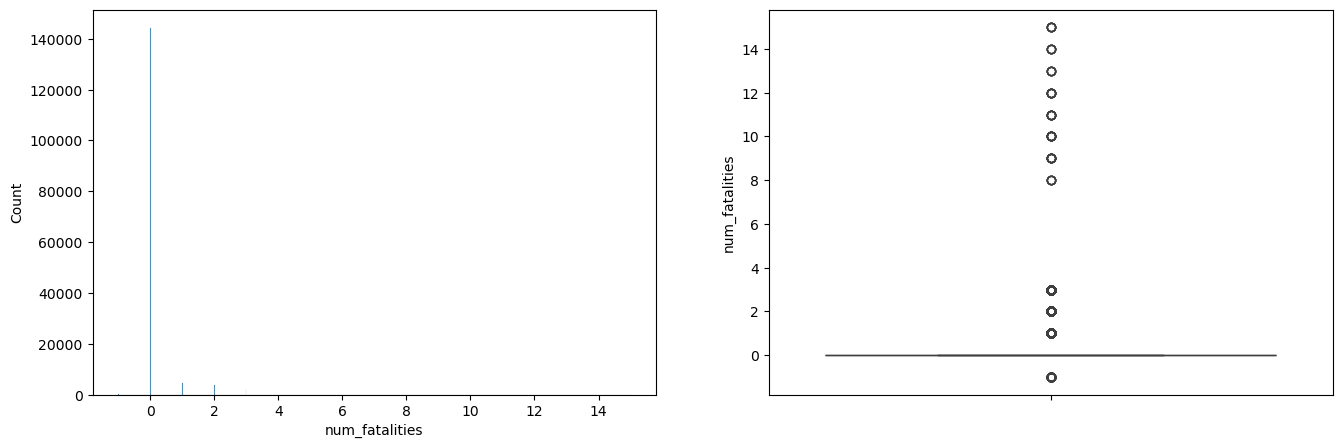

In [93]:
# num_fatalities
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['num_fatalities'])

plt.subplot(1,2,2)
sns.boxplot(df['num_fatalities'])

plt.show()

There is a value below zero which is not possible

In [94]:
df = df.drop(df[df['num_fatalities'] < 0].index)

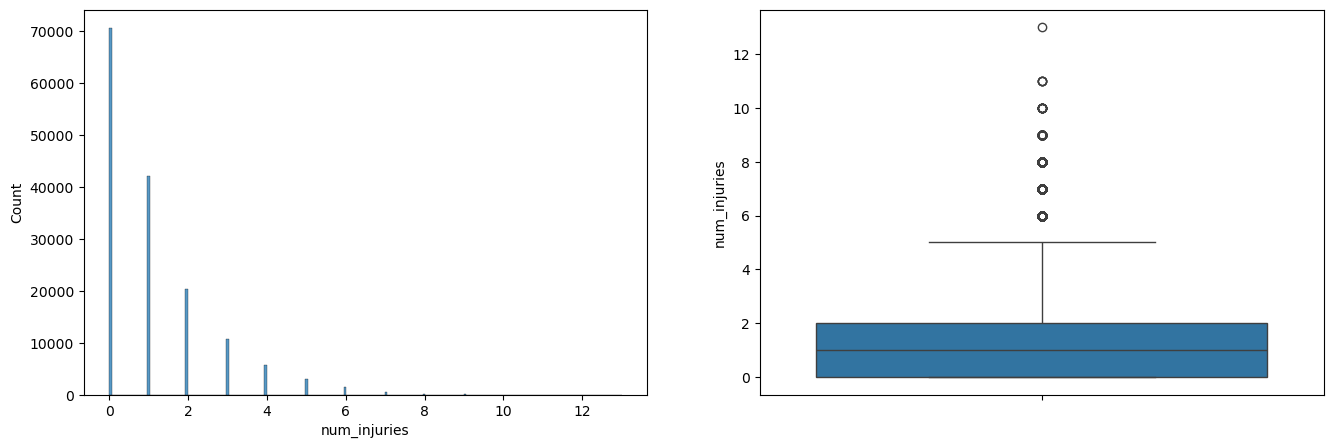

In [95]:
# num_injuries
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['num_injuries'])

plt.subplot(1,2,2)
sns.boxplot(df['num_injuries'])

plt.show()

in mostly accident there no person get injured but there is major accident where many person injured

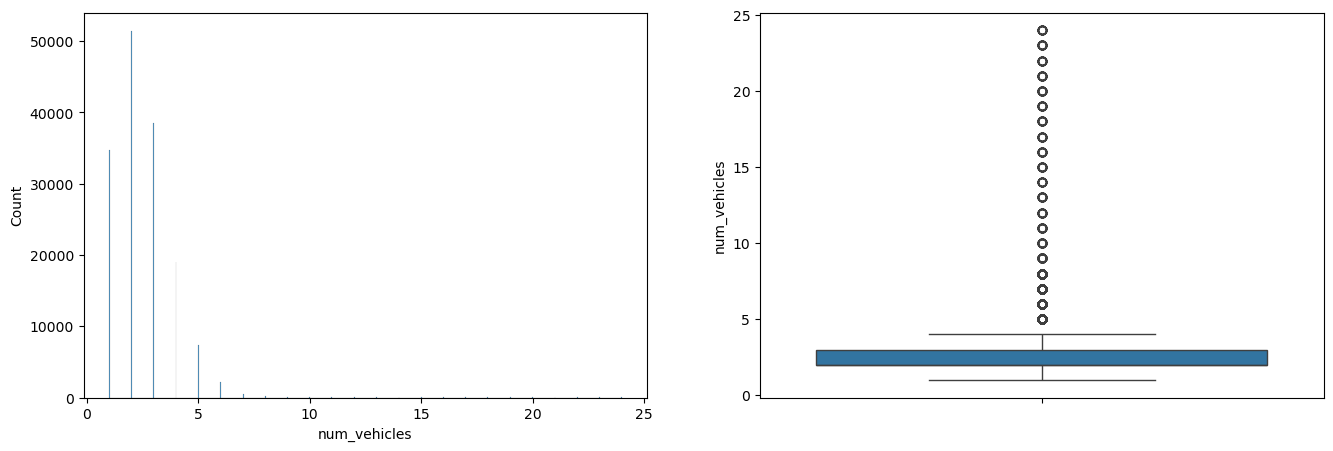

In [96]:
# num_vehicles
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['num_vehicles'])

plt.subplot(1,2,2)
sns.boxplot(df['num_vehicles'])

plt.show()

In [97]:
# Handling missing values for int_cols
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')
df[int_cols] = median_imputer.fit_transform(df[int_cols])

In [98]:
obj_col = df.select_dtypes(include=['object']).columns
for col in obj_col:
    print(col,"==>",df[col].unique())

accident_id ==> ['ACC20240000709' 'ACC20180059148' 'ACC20160076737' ... 'ACC20220041187'
 'ACC20240117449' 'ACC20190162698']
state ==> ['Karnataka' 'West Bengal' 'Rajasthan' 'Gujarat' 'Uttar Pradesh'
 'Maharashtra' 'Kerala' 'Chhattisgarh' 'Haryana' 'Assam' 'Andhra Pradesh'
 'Bihar' 'Himachal Pradesh' 'Delhi' 'Madhya Pradesh' 'Jharkhand' 'Odisha'
 'Telangana' 'Punjab' 'Tamil Nadu' 'Uttarakhand']
area_type ==> ['Rural' 'Semi-Urban' 'Urban']
road_type ==> ['State Highway' 'National Highway' 'Village Road' 'Expressway'
 'Other District Road' 'state highway' 'village road' ' National Highway '
 'NATIONAL HIGHWAY' 'VILLAGE ROAD' 'OTHER DISTRICT ROAD'
 'other district road' 'national highway' ' Village Road ' 'EXPRESSWAY'
 ' Other District Road ' ' State Highway ' 'STATE HIGHWAY' 'expressway'
 ' Expressway ']
road_condition ==> ['Pothole-Ridden' 'Under Construction' 'Dry' 'Wet' 'Loose Surface']
road_lighting ==> ['Streetlight Absent' 'Streetlight Present' nan]
junction_type ==> ['No Junction'

In [99]:
obj_col

Index(['accident_id', 'state', 'area_type', 'road_type', 'road_condition',
       'road_lighting', 'junction_type', 'traffic_signal_present',
       'median_present', 'weather_condition', 'driver_gender',
       'license_status', 'alcohol_involved', 'distraction_involved',
       'mobile_phone_used', 'fatigue_involved', 'helmet_seatbelt_used',
       'vehicle_type', 'vehicle_condition', 'primary_cause',
       'emergency_services_called', 'ambulance_called', 'police_called',
       'hospitalization_required', 'accident_severity'],
      dtype='object')

From This we got to know there is inconsistesy in data

In [100]:
df['road_type'] = df['road_type'].map({  'state highway':'State Highway', ' State Highway ':'State Highway', 'STATE HIGHWAY' : 'State Highway', 'EXPRESSWAY':'Expressway', 'expressway':'Expressway', ' Expressway ':'Expressway', 'national highway':'National Highway', ' National Highway ':'National Highway', 'NATIONAL HIGHWAY':'National Highway', 'village road':'Village Road', 'VILLAGE ROAD':'Village Road', ' Village Road ':'Village Road', 'OTHER DISTRICT ROAD':'Other District Road', 'other district road':'Other District Road', ' Other District Road ':'Other District Road'})

df['traffic_signal_present'] = df['traffic_signal_present'].map({'0':'No','N':'No','True':'Yes','False':'No','Y':'Yes','1':'Yes','Yes':'Yes','No':'No'})
df['median_present'] = df['median_present'].map({'0':'No','N':'No','True':'Yes','False':'No','Y':'Yes','1':'Yes','Yes':'Yes','No':'No'})
df['mobile_phone_used'] = df['mobile_phone_used'].map({'0':'No','N':'No','True':'Yes','False':'No','Y':'Yes','1':'Yes','Yes':'Yes','No':'No'})

df['weather_condition'] = df['weather_condition'].map({'Rainy':'Rainy','rainy':'Rainy',' Rainy ':'Rainy','RAINY':'Rainy',' Clear ':'Clear', 'clear':'Clear', 'CLEAR':'Clear',' Foggy ':'Foggy','FOGGY':'Foggy', 'foggy':'Foggy','hazy':'Hazy','HAZY':'Hazy',' Hazy ':'Hazy','STORMY':'Stormy','stormy':'Stormy',' Stormy ':'Stormy'})



In [102]:
mode_imputer = SimpleImputer(strategy='most_frequent')
df[obj_col] = mode_imputer.fit_transform(df[obj_col])

In [103]:
df.isnull().sum()

accident_id                  0
state                        0
area_type                    0
latitude                     0
longitude                    0
road_type                    0
road_condition               0
road_lighting                0
number_of_lanes              0
speed_limit_kmph             0
estimated_speed_kmph         0
junction_type                0
traffic_signal_present       0
median_present               0
weather_condition            0
visibility_km                0
temperature_c                0
rainfall_mm                  0
driver_age                   0
driver_gender                0
driving_experience_years     0
license_status               0
alcohol_involved             0
distraction_involved         0
mobile_phone_used            0
fatigue_involved             0
helmet_seatbelt_used         0
vehicle_type                 0
vehicle_age_years            0
vehicle_condition            0
primary_cause                0
emergency_services_called    0
ambulanc

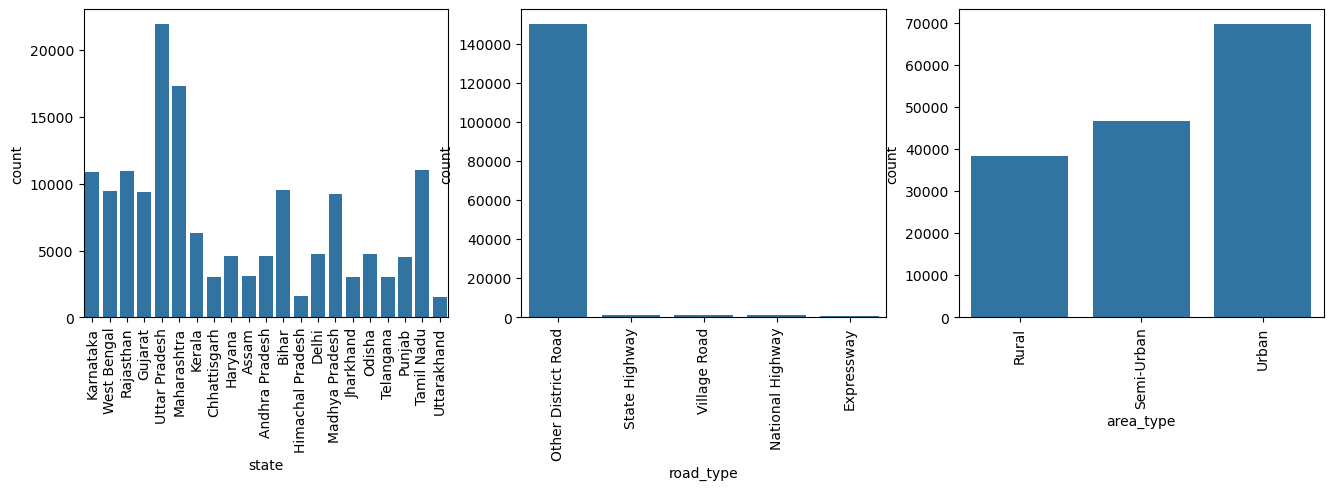

In [104]:
# state, district and road_type                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["state"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["road_type"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["area_type"])
plt.xticks(rotation=90)
plt.show()


- Mostly Accident is done in UttarPradesh , Maharashtra
- In Urban Area or SemiUrban area on Other Distict Road Mostly Accident ocour

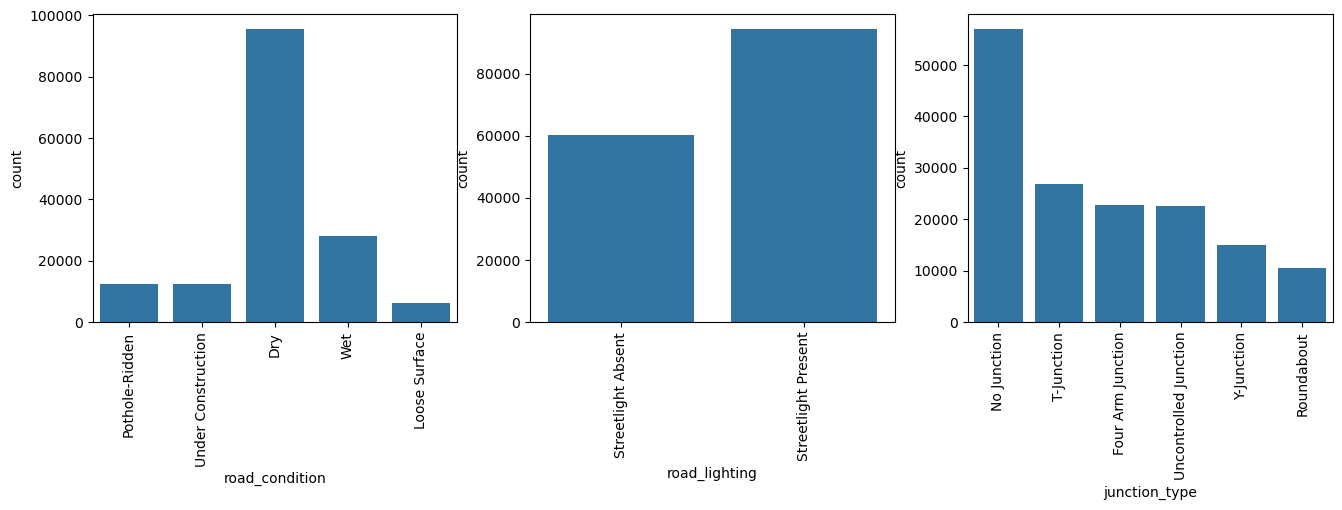

In [105]:
# road_condition, road_lighting and junction_type                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["road_condition"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["road_lighting"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["junction_type"])
plt.xticks(rotation=90)
plt.show()


It seems to be Ironical that Accident occur on dry road in the presence of Street lighting with Nojunction 

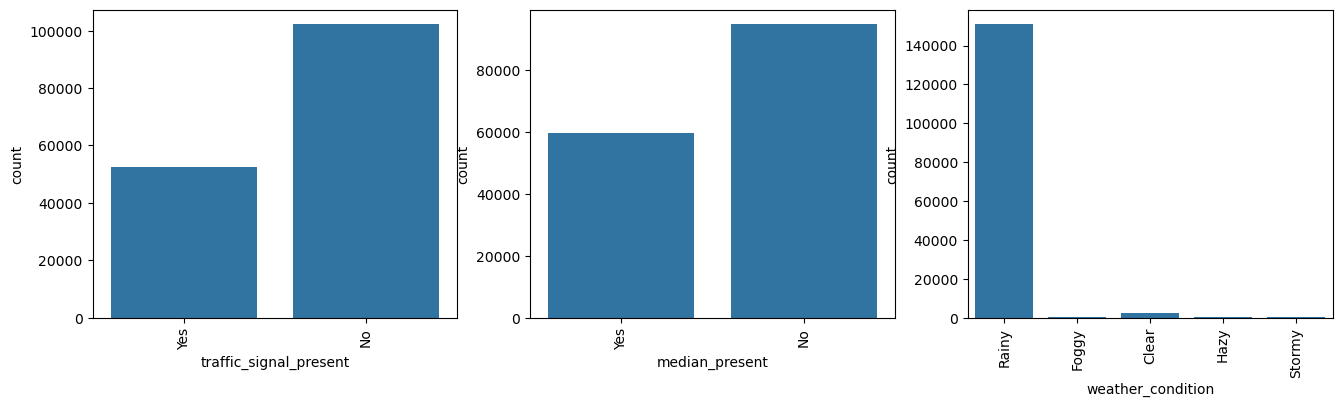

In [106]:
# traffic_signal_present, median_present and weather_condition                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["traffic_signal_present"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["median_present"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["weather_condition"])
plt.xticks(rotation=90)
plt.show()


Now the Reason is clearly Visible that Accident is happening beacuse of abbsence of traffic signal and rainy weather

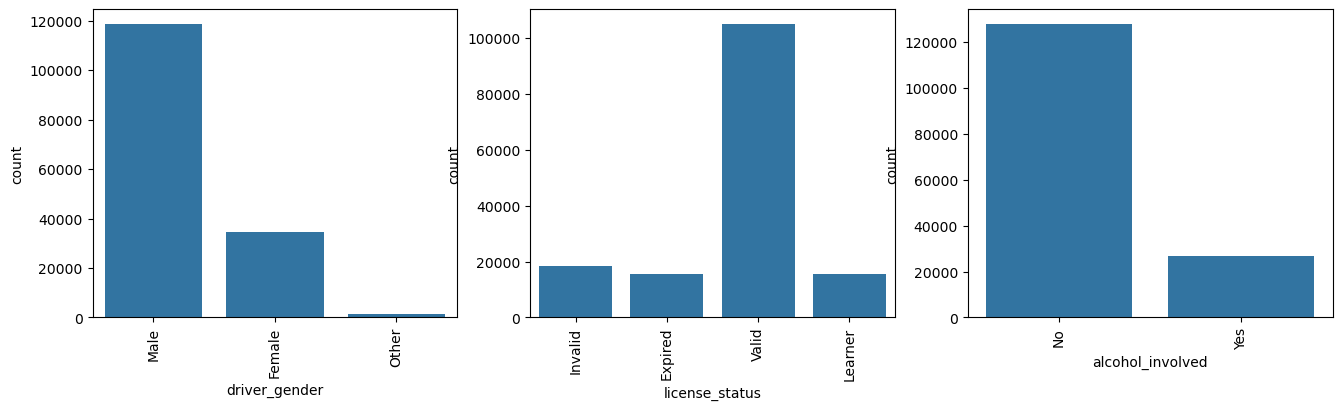

In [107]:
# driver_gender, license_status and alcohol_involved                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["driver_gender"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["license_status"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["alcohol_involved"])
plt.xticks(rotation=90)
plt.show()


- majority of accident done by a male as compare to female and others
- In few cases it is found to be involvement of alcohol

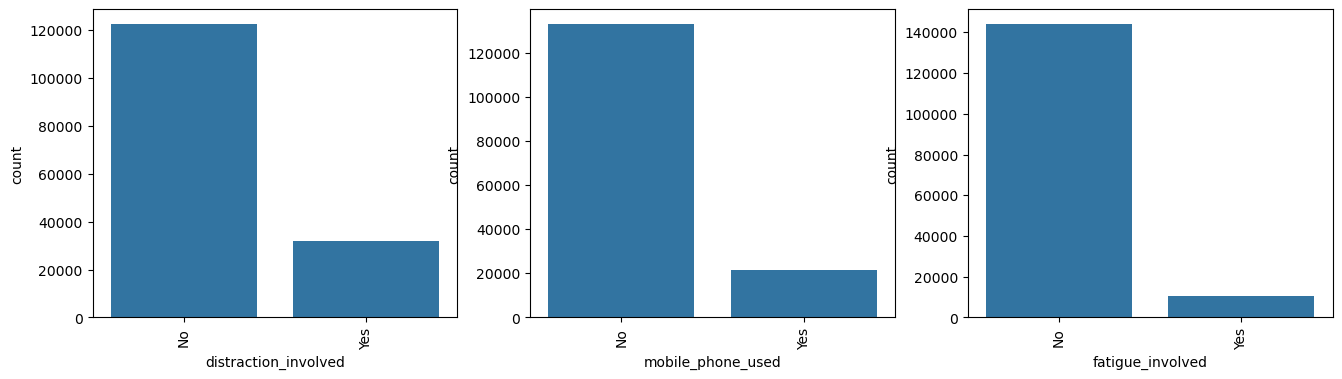

In [108]:
# distraction_involved, mobile_phone_used and fatigue_involved                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["distraction_involved"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["mobile_phone_used"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["fatigue_involved"])
plt.xticks(rotation=90)
plt.show()


It seem to be justify that all data is realistic

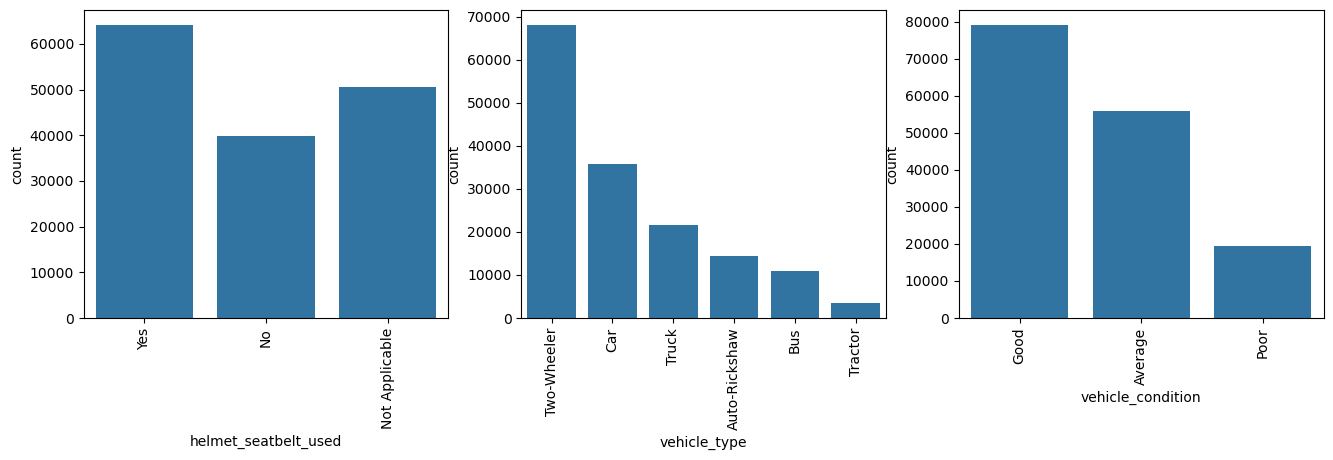

In [109]:
# helmet_seatbelt_used, vehicle_type and vehicle_condition                      

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["helmet_seatbelt_used"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["vehicle_type"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["vehicle_condition"])
plt.xticks(rotation=90)
plt.show()

- Mostly accident is done by TwoWheeler
- Majority of vehicle has good and average condition

- Primary Cause is poorRoad Condition, Drunk Driving, Distracted Driver, Weather, Overspeeding
- Secondary Cause is Overspeeding

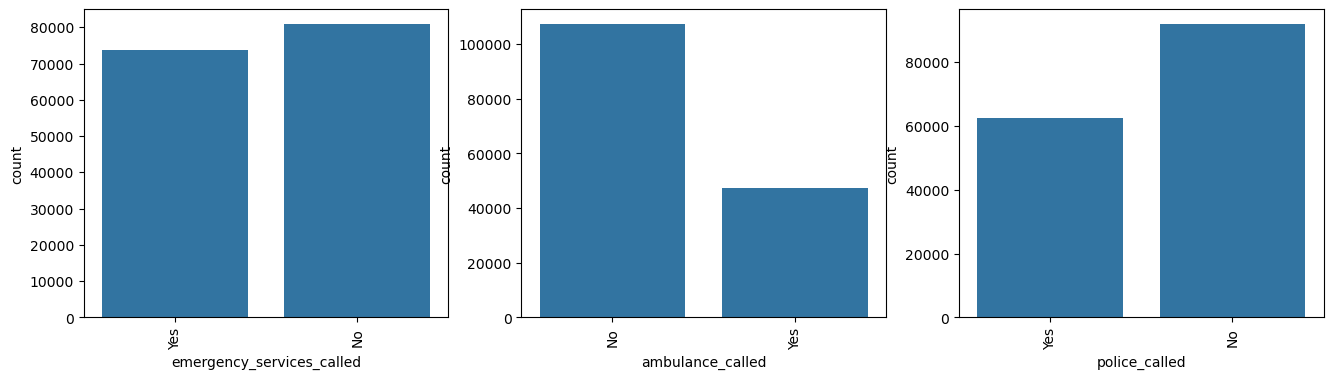

In [111]:
# emergency_services_called, ambulance_called and police_called                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["emergency_services_called"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["ambulance_called"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["police_called"])
plt.xticks(rotation=90)
plt.show()

- Approx 50 percent people called the emergencyService
- majority people not called the Ambulance and Police

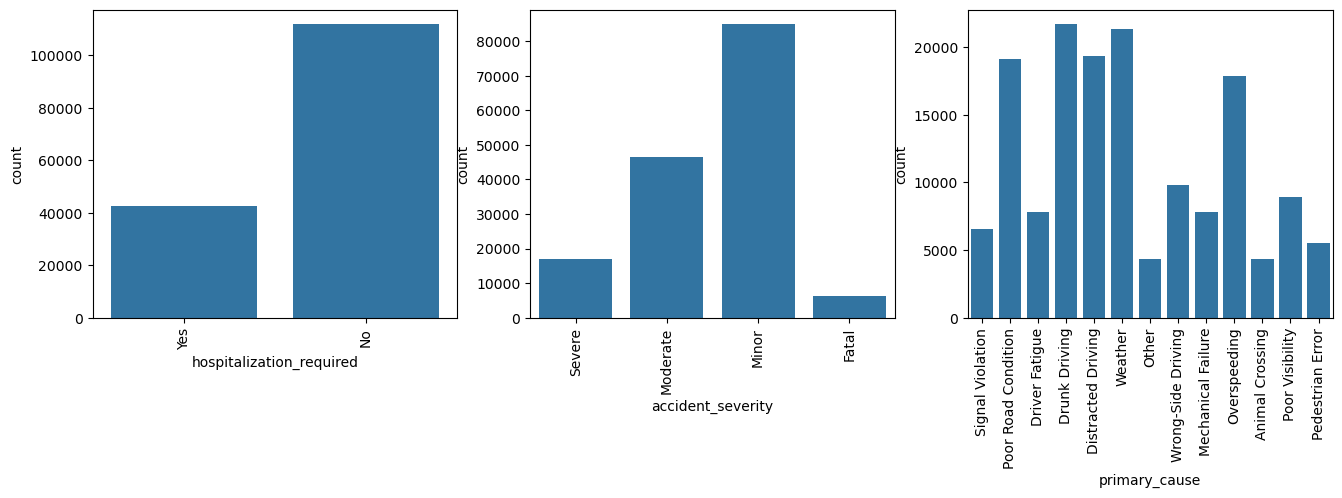

In [113]:
# hospitalization_required, accident_severity and primary_cause                        

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=df["hospitalization_required"])
plt.xticks(rotation=90)
plt.subplot(1,3,2)
sns.countplot(x=df["accident_severity"])
plt.xticks(rotation=90)
plt.subplot(1,3,3)
sns.countplot(x=df["primary_cause"])
plt.xticks(rotation=90)
plt.show()

- From first two graph it seem that majority of accident are minor
- And more than 50% people claimed Insuarance

## BIVARIANT ANALYSIS

<Axes: >

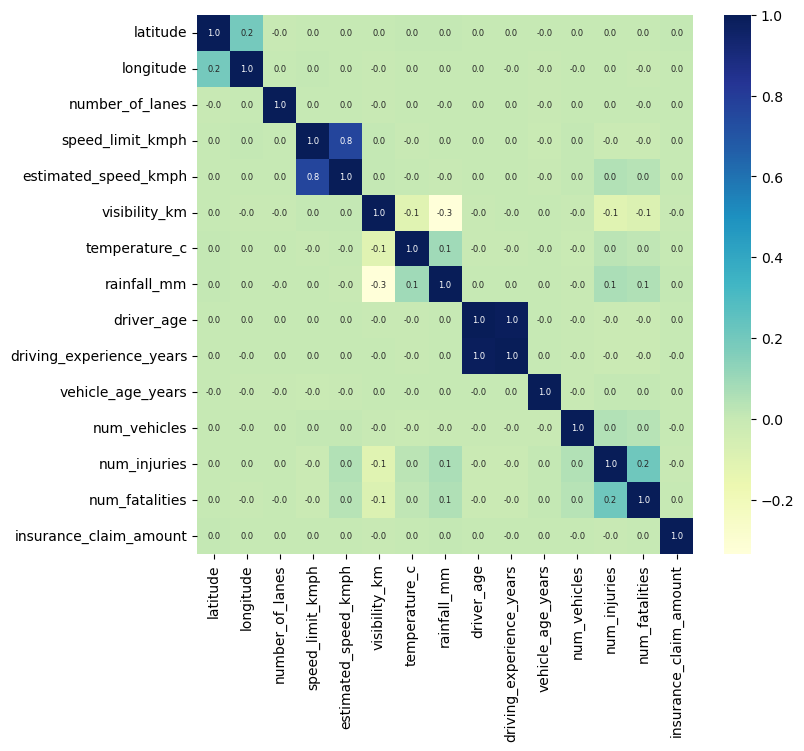

In [114]:
plt.figure(figsize=(8,7))
sns.heatmap(df.corr(numeric_only = True) , annot = True , fmt = '.1f' , cmap = 'YlGnBu' , annot_kws = {'size':6})

By this heatmap we get few column to compare
- estimated_speed_kmph vs speed_limit_kmph
- num_fatalities vs num_injuries
- longitude vs latitude

Text(0, 0.5, 'Speed Limit (km/h)')

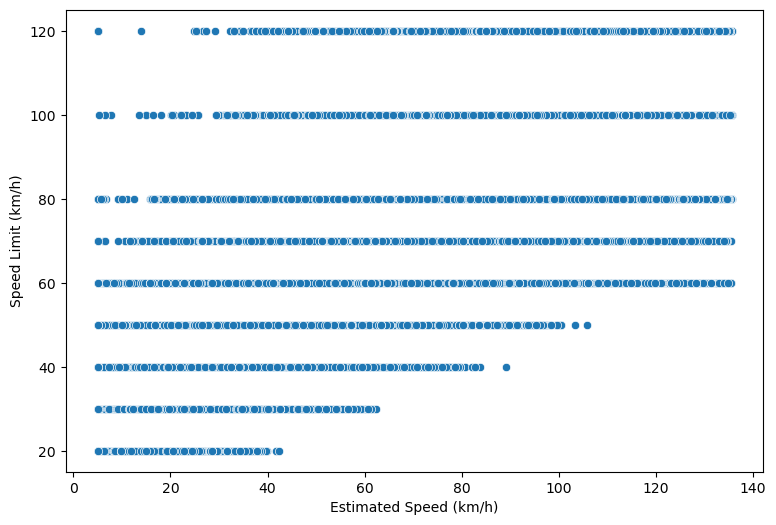

In [115]:
plt.figure(figsize=(9,6))
sns.scatterplot(x=df["estimated_speed_kmph"],y=df["speed_limit_kmph"])
plt.xlabel("Estimated Speed (km/h)")
plt.ylabel("Speed Limit (km/h)")

As the speedlimit Increase Estimated speed also increase

<Axes: xlabel='num_fatalities', ylabel='num_injuries'>

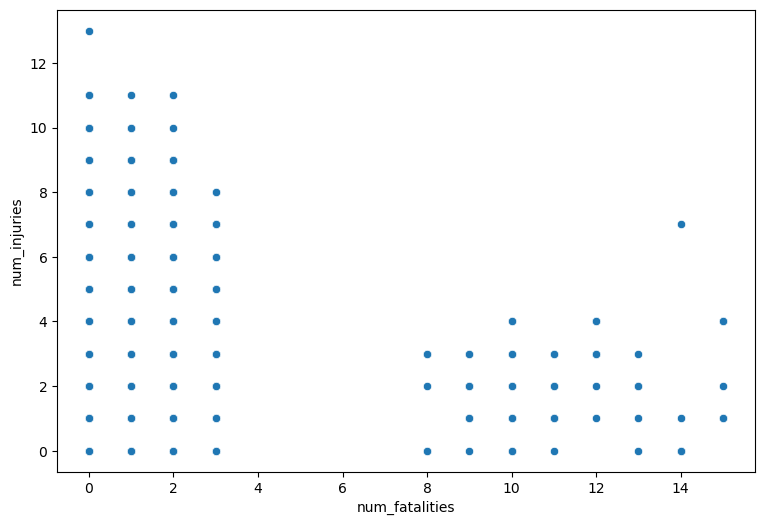

In [116]:
plt.figure(figsize=(9,6))
sns.scatterplot(x=df["num_fatalities"],y=df["num_injuries"])

<Axes: xlabel='latitude', ylabel='longitude'>

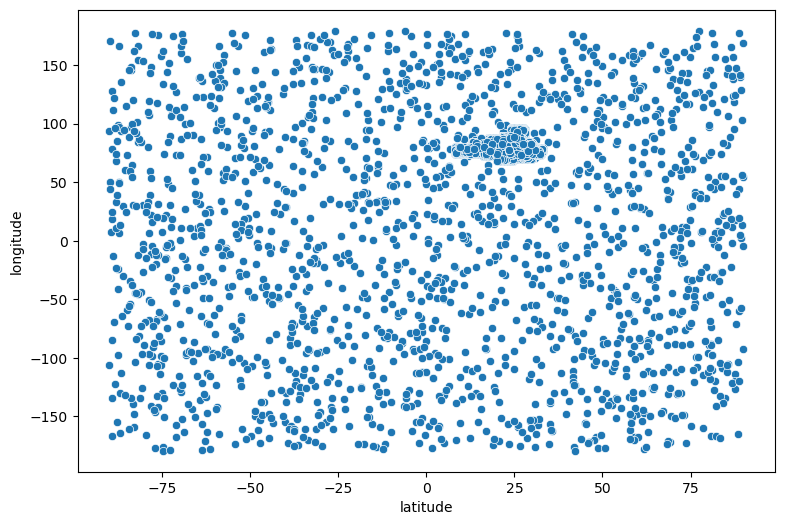

In [117]:
plt.figure(figsize=(9,6))
sns.scatterplot(x=df["latitude"],y=df["longitude"])

In [118]:
obj_col

Index(['accident_id', 'state', 'area_type', 'road_type', 'road_condition',
       'road_lighting', 'junction_type', 'traffic_signal_present',
       'median_present', 'weather_condition', 'driver_gender',
       'license_status', 'alcohol_involved', 'distraction_involved',
       'mobile_phone_used', 'fatigue_involved', 'helmet_seatbelt_used',
       'vehicle_type', 'vehicle_condition', 'primary_cause',
       'emergency_services_called', 'ambulance_called', 'police_called',
       'hospitalization_required', 'accident_severity'],
      dtype='object')

<Axes: xlabel='vehicle_type', ylabel='accident_severity'>

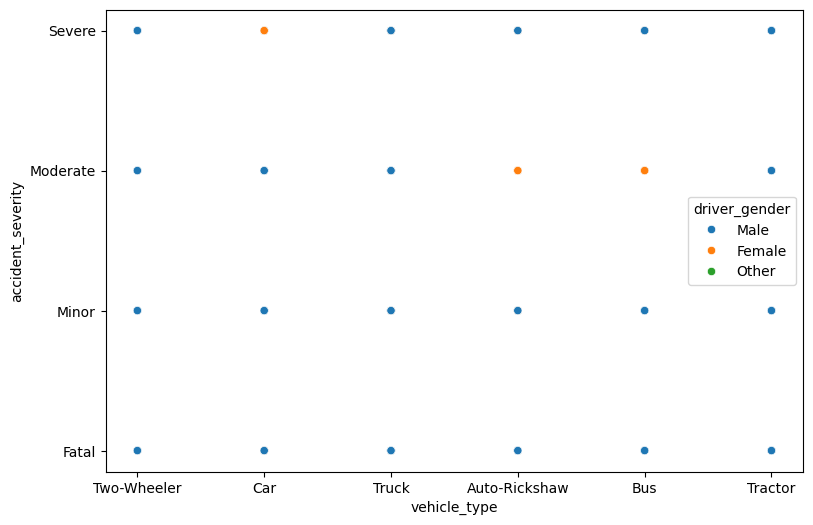

In [119]:
plt.figure(figsize=(9,6))
sns.scatterplot(y=df["accident_severity"],x=df["vehicle_type"], hue=df["driver_gender"])

<Axes: xlabel='driver_gender', ylabel='count'>

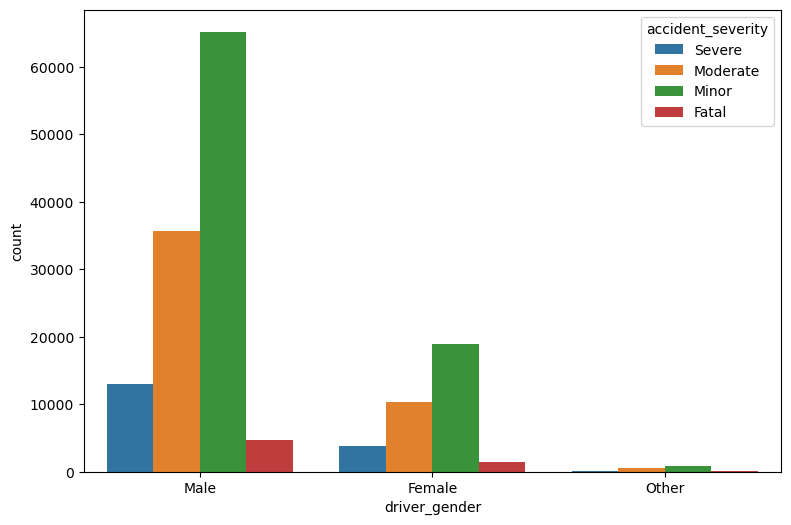

In [120]:
plt.figure(figsize=(9,6))
sns.countplot(x='driver_gender', hue='accident_severity', data=df)

In [121]:
df.to_csv("EDA_done.csv")